# Project 3: KMNIST Deep Learning Experiments

This notebook implements and compares two Keras image-classification models on the Kuzushiji-MNIST data set

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

import kmnist_experiments as km

## Setup

1. Load the data
2. Preprocess images into 4d tensors
3. Train and tune an MLP baseline
4. Train and tune a small CNN
5. Evaluate the best models on the test set

Train data shapes: (60000, 28, 28), (60000,)
Test data shapes: (10000, 28, 28), (10000,)
Class names: ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']


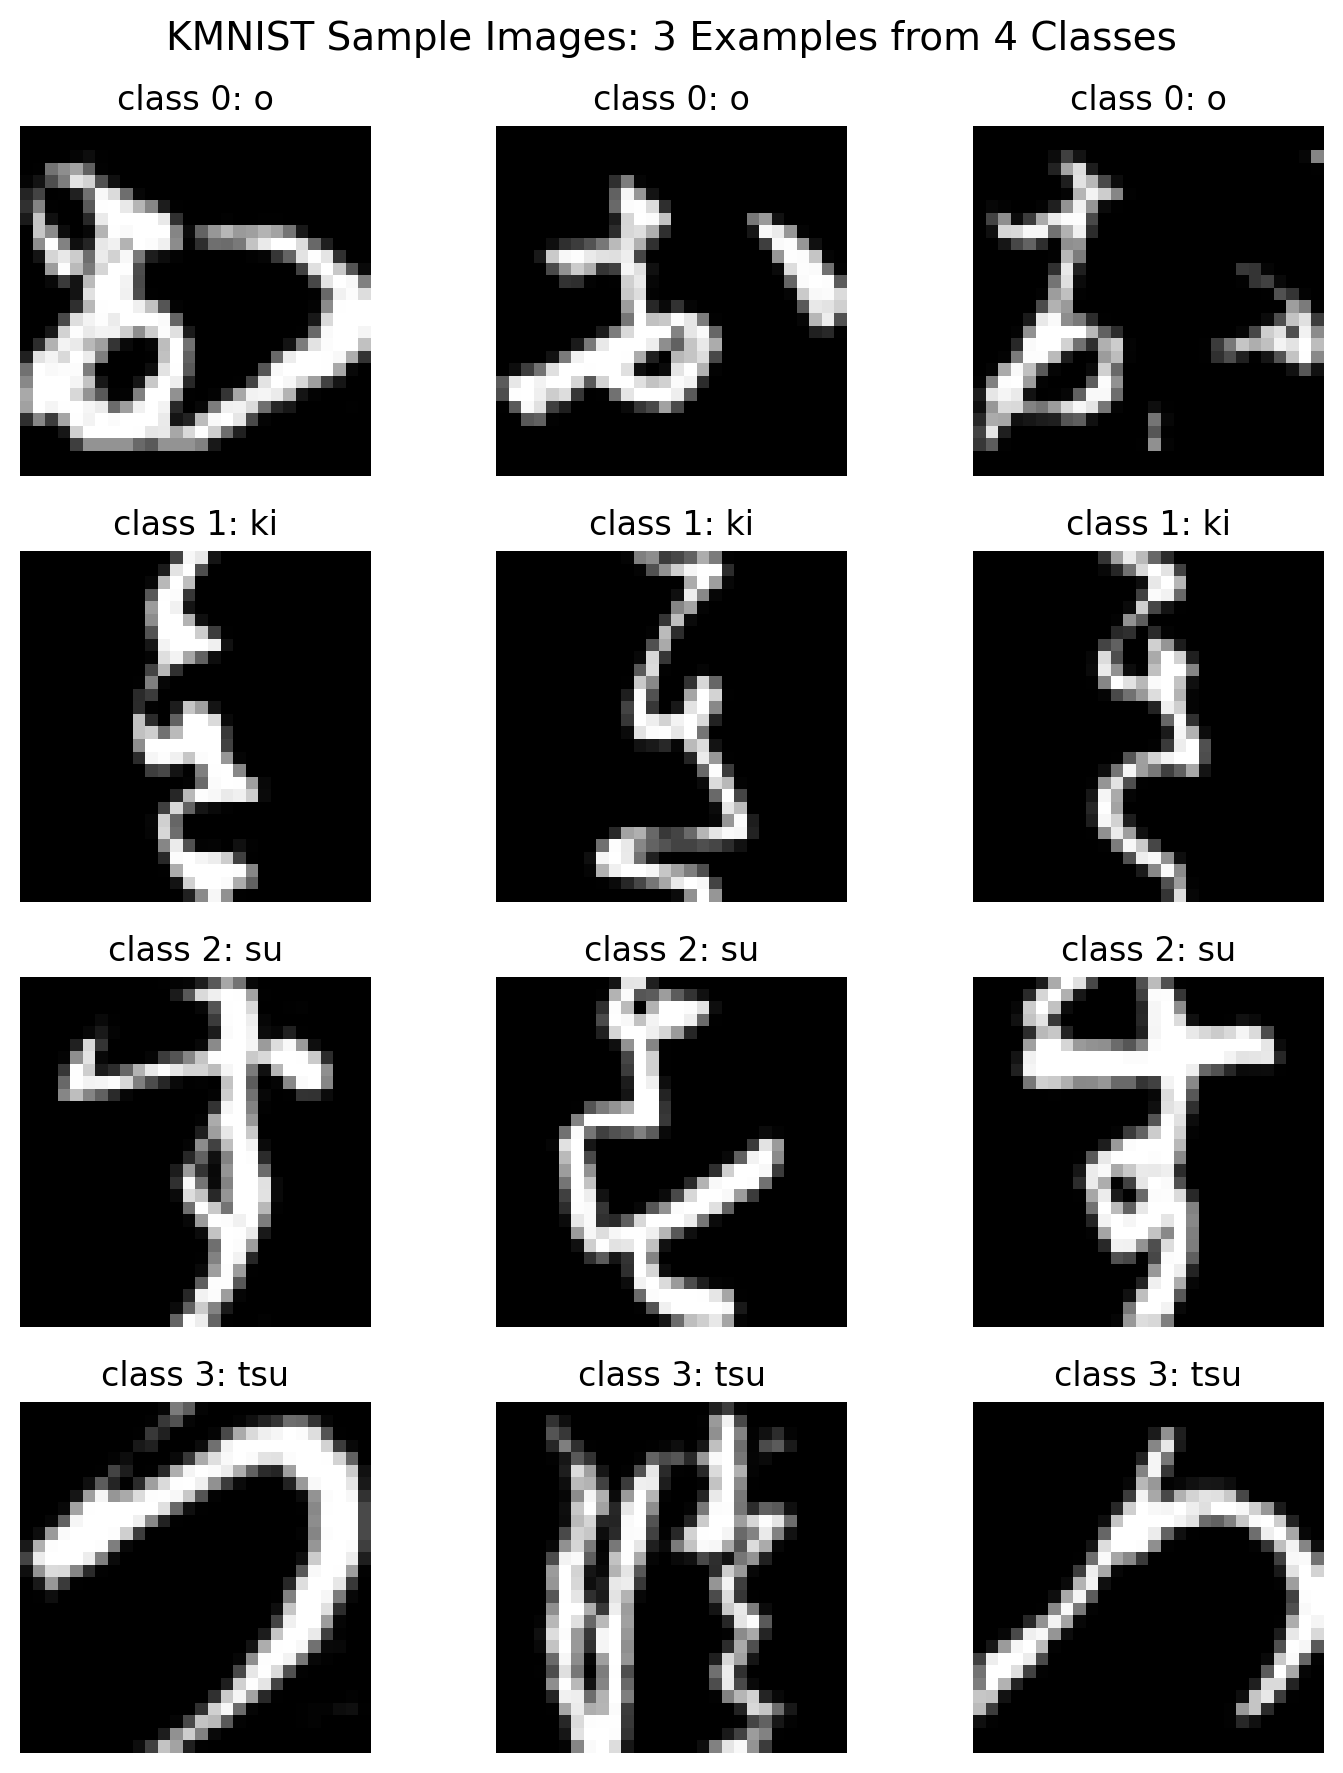

In [4]:
train_images_raw, train_labels, test_images_raw, test_labels = km.load_kmnist_data()
km.save_dataset_summary(train_images_raw, train_labels, test_images_raw, test_labels)
km.plot_sample_grid(train_images_raw, train_labels)

print(f"Train data shapes: {train_images_raw.shape}, {train_labels.shape}")
print(f"Test data shapes: {test_images_raw.shape}, {test_labels.shape}")
print(f"Class names: {km.CLASS_NAMES}")

sample_grid_path = km.FIGURES_DIR / "sample_grid_4_classes.png"
display(Image(filename=str(sample_grid_path)))

In [5]:
train_images = km.preprocess_images(train_images_raw)
test_images = km.preprocess_images(test_images_raw)
train_images, val_images, train_labels_split, val_labels = km.make_train_validation_split(
    train_images,
    train_labels,
)

print(f"Reshaped training tensor: {train_images.shape}")
print(f"Validation tensor: {val_images.shape}")
print(f"Reshaped test tensor: {test_images.shape}")
print(f"Training dtype: {train_images.dtype}")
print(f"Scaled pixel range: min={train_images.min():.3f}, max={train_images.max():.3f}")

Reshaped training tensor: (54000, 28, 28, 1)
Validation tensor: (6000, 28, 28, 1)
Reshaped test tensor: (10000, 28, 28, 1)
Training dtype: float32
Scaled pixel range: min=0.000, max=1.000


## MLP Baseline

- an input layer
- a flatten layer
- two dense hidden layers with ReLU
- a dense layer with 10 softmax outputs

In [6]:
mlp_baseline = km.build_mlp(hidden_layers=2, unit_pair=(8, 8), optimizer="adam")
mlp_baseline.summary()

Model: "mlp_h2_8_8_adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         6,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,442 (25.16 KB)

 Trainable params: 6,442 (25.16 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
mlp_results = km.run_mlp_search(
    train_images=train_images,
    train_labels=train_labels_split,
    val_images=val_images,
    val_labels=val_labels,
    test_images=test_images,
    test_labels=test_labels,
    config=km.FULL_MLP_CONFIG,
)
km.write_experiment_table(km.METRICS_DIR / "mlp_experiment_results.csv", mlp_results)

best_mlp = km.select_best_result(mlp_results)
best_dense_units = km.parse_mlp_units(best_mlp.config_name)

sorted_mlp_results = sorted(
    mlp_results,
    key=lambda item: (item.best_val_accuracy, item.test_accuracy),
    reverse=True,
)

print(f"MLP experiments completed: {len(mlp_results)}")
print(f"Best MLP config: {best_mlp.config_name}")
print(f"Best MLP validation accuracy: {best_mlp.best_val_accuracy:.4f}")
print(f"Best MLP test accuracy: {best_mlp.test_accuracy:.4f}")
print("\nTop MLP runs:")
for result in sorted_mlp_results[:5]:
    print(
        f"- {result.config_name}: val={result.best_val_accuracy:.4f}, "
        f"test={result.test_accuracy:.4f}, params={result.params}"
    )

Epoch 1/10
422/422 - 2s - 4ms/step - accuracy: 0.7368 - loss: 0.9060 - val_accuracy: 0.7990 - val_loss: 0.6931
Epoch 2/10
422/422 - 1s - 2ms/step - accuracy: 0.8107 - loss: 0.6484 - val_accuracy: 0.8098 - val_loss: 0.6432
Epoch 3/10
422/422 - 1s - 2ms/step - accuracy: 0.8185 - loss: 0.6152 - val_accuracy: 0.8108 - val_loss: 0.6264
Epoch 4/10
422/422 - 1s - 2ms/step - accuracy: 0.8237 - loss: 0.6000 - val_accuracy: 0.8145 - val_loss: 0.6188
Epoch 5/10
422/422 - 1s - 2ms/step - accuracy: 0.8268 - loss: 0.5900 - val_accuracy: 0.8163 - val_loss: 0.6149
Epoch 6/10
422/422 - 1s - 2ms/step - accuracy: 0.8284 - loss: 0.5828 - val_accuracy: 0.8140 - val_loss: 0.6163
Epoch 7/10
422/422 - 1s - 2ms/step - accuracy: 0.8315 - loss: 0.5780 - val_accuracy: 0.8202 - val_loss: 0.6098
Epoch 8/10
422/422 - 1s - 2ms/step - accuracy: 0.8322 - loss: 0.5736 - val_accuracy: 0.8190 - val_loss: 0.6113
Epoch 9/10
422/422 - 1s - 2ms/step - accuracy: 0.8331 - loss: 0.5696 - val_accuracy: 0.8187 - val_loss: 0.6142
E

Epoch 1/15
422/422 - 1s - 3ms/step - accuracy: 0.7300 - loss: 0.9242 - val_accuracy: 0.7995 - val_loss: 0.6969
Epoch 2/15
422/422 - 1s - 2ms/step - accuracy: 0.8078 - loss: 0.6529 - val_accuracy: 0.8090 - val_loss: 0.6439
Epoch 3/15
422/422 - 1s - 2ms/step - accuracy: 0.8174 - loss: 0.6176 - val_accuracy: 0.8135 - val_loss: 0.6299
Epoch 4/15
422/422 - 1s - 2ms/step - accuracy: 0.8229 - loss: 0.6017 - val_accuracy: 0.8163 - val_loss: 0.6199
Epoch 5/15
422/422 - 1s - 2ms/step - accuracy: 0.8257 - loss: 0.5914 - val_accuracy: 0.8190 - val_loss: 0.6151
Epoch 6/15
422/422 - 1s - 2ms/step - accuracy: 0.8293 - loss: 0.5840 - val_accuracy: 0.8177 - val_loss: 0.6152
Epoch 7/15
422/422 - 1s - 2ms/step - accuracy: 0.8297 - loss: 0.5790 - val_accuracy: 0.8172 - val_loss: 0.6153
Epoch 8/15
422/422 - 1s - 2ms/step - accuracy: 0.8315 - loss: 0.5739 - val_accuracy: 0.8175 - val_loss: 0.6110
Epoch 9/15
422/422 - 1s - 2ms/step - accuracy: 0.8322 - loss: 0.5707 - val_accuracy: 0.8190 - val_loss: 0.6133
E

Epoch 1/10
422/422 - 1s - 3ms/step - accuracy: 0.7508 - loss: 0.8637 - val_accuracy: 0.8032 - val_loss: 0.6720
Epoch 2/10
422/422 - 1s - 2ms/step - accuracy: 0.8127 - loss: 0.6369 - val_accuracy: 0.8102 - val_loss: 0.6339
Epoch 3/10
422/422 - 1s - 2ms/step - accuracy: 0.8213 - loss: 0.6106 - val_accuracy: 0.8133 - val_loss: 0.6305
Epoch 4/10
422/422 - 1s - 2ms/step - accuracy: 0.8248 - loss: 0.5970 - val_accuracy: 0.8182 - val_loss: 0.6145
Epoch 5/10
422/422 - 1s - 2ms/step - accuracy: 0.8282 - loss: 0.5892 - val_accuracy: 0.8170 - val_loss: 0.6153
Epoch 6/10
422/422 - 1s - 2ms/step - accuracy: 0.8298 - loss: 0.5833 - val_accuracy: 0.8198 - val_loss: 0.6118
Epoch 7/10
422/422 - 1s - 2ms/step - accuracy: 0.8320 - loss: 0.5785 - val_accuracy: 0.8180 - val_loss: 0.6131
Epoch 8/10
422/422 - 1s - 2ms/step - accuracy: 0.8326 - loss: 0.5749 - val_accuracy: 0.8190 - val_loss: 0.6118
Epoch 9/10
422/422 - 1s - 2ms/step - accuracy: 0.8334 - loss: 0.5713 - val_accuracy: 0.8160 - val_loss: 0.6134
E

Epoch 1/15
422/422 - 1s - 3ms/step - accuracy: 0.7534 - loss: 0.8526 - val_accuracy: 0.8013 - val_loss: 0.6693
Epoch 2/15
422/422 - 1s - 2ms/step - accuracy: 0.8126 - loss: 0.6367 - val_accuracy: 0.8122 - val_loss: 0.6326
Epoch 3/15
422/422 - 1s - 2ms/step - accuracy: 0.8206 - loss: 0.6097 - val_accuracy: 0.8168 - val_loss: 0.6208
Epoch 4/15
422/422 - 1s - 2ms/step - accuracy: 0.8249 - loss: 0.5969 - val_accuracy: 0.8190 - val_loss: 0.6167
Epoch 5/15
422/422 - 1s - 2ms/step - accuracy: 0.8278 - loss: 0.5889 - val_accuracy: 0.8168 - val_loss: 0.6155
Epoch 6/15
422/422 - 1s - 2ms/step - accuracy: 0.8301 - loss: 0.5831 - val_accuracy: 0.8195 - val_loss: 0.6160
Epoch 7/15
422/422 - 1s - 2ms/step - accuracy: 0.8313 - loss: 0.5786 - val_accuracy: 0.8195 - val_loss: 0.6097
Epoch 8/15
422/422 - 1s - 2ms/step - accuracy: 0.8321 - loss: 0.5747 - val_accuracy: 0.8210 - val_loss: 0.6115
Epoch 9/15
422/422 - 1s - 2ms/step - accuracy: 0.8339 - loss: 0.5708 - val_accuracy: 0.8153 - val_loss: 0.6168
E

Epoch 1/10
422/422 - 1s - 3ms/step - accuracy: 0.7381 - loss: 0.9059 - val_accuracy: 0.7978 - val_loss: 0.6925
Epoch 2/10
422/422 - 1s - 2ms/step - accuracy: 0.8094 - loss: 0.6493 - val_accuracy: 0.8085 - val_loss: 0.6460
Epoch 3/10
422/422 - 1s - 2ms/step - accuracy: 0.8183 - loss: 0.6164 - val_accuracy: 0.8145 - val_loss: 0.6271
Epoch 4/10
422/422 - 1s - 2ms/step - accuracy: 0.8234 - loss: 0.6007 - val_accuracy: 0.8162 - val_loss: 0.6205
Epoch 5/10
422/422 - 1s - 2ms/step - accuracy: 0.8271 - loss: 0.5914 - val_accuracy: 0.8153 - val_loss: 0.6191
Epoch 6/10
422/422 - 1s - 2ms/step - accuracy: 0.8282 - loss: 0.5842 - val_accuracy: 0.8157 - val_loss: 0.6151
Epoch 7/10
422/422 - 1s - 2ms/step - accuracy: 0.8309 - loss: 0.5791 - val_accuracy: 0.8180 - val_loss: 0.6130
Epoch 8/10
422/422 - 1s - 2ms/step - accuracy: 0.8321 - loss: 0.5743 - val_accuracy: 0.8188 - val_loss: 0.6117
Epoch 9/10
422/422 - 1s - 2ms/step - accuracy: 0.8332 - loss: 0.5702 - val_accuracy: 0.8180 - val_loss: 0.6110
E

...

Epoch 1/10
422/422 - 2s - 6ms/step - accuracy: 0.8089 - loss: 0.6356 - val_accuracy: 0.8895 - val_loss: 0.3720
Epoch 2/10
422/422 - 1s - 2ms/step - accuracy: 0.9062 - loss: 0.3129 - val_accuracy: 0.9140 - val_loss: 0.2911
Epoch 3/10
422/422 - 1s - 2ms/step - accuracy: 0.9269 - loss: 0.2462 - val_accuracy: 0.9235 - val_loss: 0.2600
Epoch 4/10
422/422 - 1s - 3ms/step - accuracy: 0.9406 - loss: 0.2018 - val_accuracy: 0.9273 - val_loss: 0.2449
Epoch 5/10
422/422 - 1s - 2ms/step - accuracy: 0.9471 - loss: 0.1774 - val_accuracy: 0.9315 - val_loss: 0.2274
Epoch 6/10
422/422 - 1s - 2ms/step - accuracy: 0.9538 - loss: 0.1542 - val_accuracy: 0.9362 - val_loss: 0.2172
Epoch 7/10
422/422 - 1s - 3ms/step - accuracy: 0.9595 - loss: 0.1357 - val_accuracy: 0.9372 - val_loss: 0.2170
Epoch 8/10
422/422 - 1s - 2ms/step - accuracy: 0.9637 - loss: 0.1204 - val_accuracy: 0.9368 - val_loss: 0.2143
Epoch 9/10
422/422 - 1s - 3ms/step - accuracy: 0.9666 - loss: 0.1089 - val_accuracy: 0.9410 - val_loss: 0.2093
E

Epoch 1/15
422/422 - 3s - 6ms/step - accuracy: 0.8055 - loss: 0.6401 - val_accuracy: 0.8902 - val_loss: 0.3695
Epoch 2/15
422/422 - 1s - 3ms/step - accuracy: 0.9053 - loss: 0.3123 - val_accuracy: 0.9140 - val_loss: 0.2925
Epoch 3/15
422/422 - 1s - 3ms/step - accuracy: 0.9275 - loss: 0.2428 - val_accuracy: 0.9223 - val_loss: 0.2647
Epoch 4/15
422/422 - 1s - 3ms/step - accuracy: 0.9397 - loss: 0.2020 - val_accuracy: 0.9233 - val_loss: 0.2484
Epoch 5/15
422/422 - 1s - 3ms/step - accuracy: 0.9493 - loss: 0.1714 - val_accuracy: 0.9317 - val_loss: 0.2256
Epoch 6/15
422/422 - 1s - 3ms/step - accuracy: 0.9564 - loss: 0.1466 - val_accuracy: 0.9365 - val_loss: 0.2287
Epoch 7/15
422/422 - 2s - 4ms/step - accuracy: 0.9619 - loss: 0.1276 - val_accuracy: 0.9375 - val_loss: 0.2263
Epoch 8/15
422/422 - 1s - 2ms/step - accuracy: 0.9669 - loss: 0.1137 - val_accuracy: 0.9332 - val_loss: 0.2458
Epoch 9/15
422/422 - 1s - 3ms/step - accuracy: 0.9709 - loss: 0.0993 - val_accuracy: 0.9373 - val_loss: 0.2325
E

Epoch 1/10
422/422 - 2s - 5ms/step - accuracy: 0.8023 - loss: 0.6514 - val_accuracy: 0.8837 - val_loss: 0.3979
Epoch 2/10
422/422 - 1s - 2ms/step - accuracy: 0.8990 - loss: 0.3357 - val_accuracy: 0.8998 - val_loss: 0.3266
Epoch 3/10
422/422 - 1s - 2ms/step - accuracy: 0.9233 - loss: 0.2597 - val_accuracy: 0.9238 - val_loss: 0.2613
Epoch 4/10
422/422 - 1s - 2ms/step - accuracy: 0.9357 - loss: 0.2151 - val_accuracy: 0.9270 - val_loss: 0.2477
Epoch 5/10
422/422 - 1s - 2ms/step - accuracy: 0.9454 - loss: 0.1835 - val_accuracy: 0.9237 - val_loss: 0.2562
Epoch 6/10
422/422 - 1s - 2ms/step - accuracy: 0.9517 - loss: 0.1605 - val_accuracy: 0.9343 - val_loss: 0.2231
Epoch 7/10
422/422 - 1s - 2ms/step - accuracy: 0.9574 - loss: 0.1406 - val_accuracy: 0.9370 - val_loss: 0.2232
Epoch 8/10
422/422 - 1s - 2ms/step - accuracy: 0.9622 - loss: 0.1259 - val_accuracy: 0.9372 - val_loss: 0.2199
Epoch 9/10
422/422 - 1s - 2ms/step - accuracy: 0.9662 - loss: 0.1128 - val_accuracy: 0.9375 - val_loss: 0.2274
E

Epoch 1/15
422/422 - 2s - 4ms/step - accuracy: 0.7995 - loss: 0.6508 - val_accuracy: 0.8878 - val_loss: 0.3826
Epoch 2/15
422/422 - 1s - 2ms/step - accuracy: 0.8982 - loss: 0.3346 - val_accuracy: 0.9065 - val_loss: 0.3158
Epoch 3/15
422/422 - 1s - 2ms/step - accuracy: 0.9236 - loss: 0.2569 - val_accuracy: 0.9225 - val_loss: 0.2762
Epoch 4/15
422/422 - 1s - 2ms/step - accuracy: 0.9361 - loss: 0.2113 - val_accuracy: 0.9280 - val_loss: 0.2539
Epoch 5/15
422/422 - 1s - 2ms/step - accuracy: 0.9457 - loss: 0.1807 - val_accuracy: 0.9350 - val_loss: 0.2354
Epoch 6/15
422/422 - 1s - 2ms/step - accuracy: 0.9524 - loss: 0.1579 - val_accuracy: 0.9353 - val_loss: 0.2322
Epoch 7/15
422/422 - 1s - 2ms/step - accuracy: 0.9575 - loss: 0.1404 - val_accuracy: 0.9380 - val_loss: 0.2243
Epoch 8/15
422/422 - 1s - 2ms/step - accuracy: 0.9627 - loss: 0.1248 - val_accuracy: 0.9390 - val_loss: 0.2226
Epoch 9/15
422/422 - 1s - 2ms/step - accuracy: 0.9663 - loss: 0.1124 - val_accuracy: 0.9367 - val_loss: 0.2367
E

MLP experiments completed: 48
Best MLP config: mlp_h2_u64_32_rmsprop_e15
Best MLP validation accuracy: 0.9448
Best MLP test accuracy: 0.8618

Top MLP runs:
- mlp_h2_u64_32_rmsprop_e15: val=0.9448, test=0.8618, params=52650
- mlp_h3_u64_32_rmsprop_e15: val=0.9440, test=0.8698, params=53706
- mlp_h1_u64_32_rmsprop_e15: val=0.9432, test=0.8672, params=50890
- mlp_h2_u64_32_adam_e15: val=0.9422, test=0.8630, params=52650
- mlp_h1_u64_32_adam_e15: val=0.9420, test=0.8680, params=50890


Best MLP overall test accuracy: 0.8618
Per-class test accuracy:
- class 0 (o): 0.9090 (909/1000)
- class 1 (ki): 0.8470 (847/1000)
- class 2 (su): 0.7500 (750/1000)
- class 3 (tsu): 0.9110 (911/1000)
- class 4 (na): 0.8370 (837/1000)
- class 5 (ha): 0.8900 (890/1000)
- class 6 (ma): 0.9310 (931/1000)
- class 7 (ya): 0.8020 (802/1000)
- class 8 (re): 0.8640 (864/1000)
- class 9 (wo): 0.8770 (877/1000)


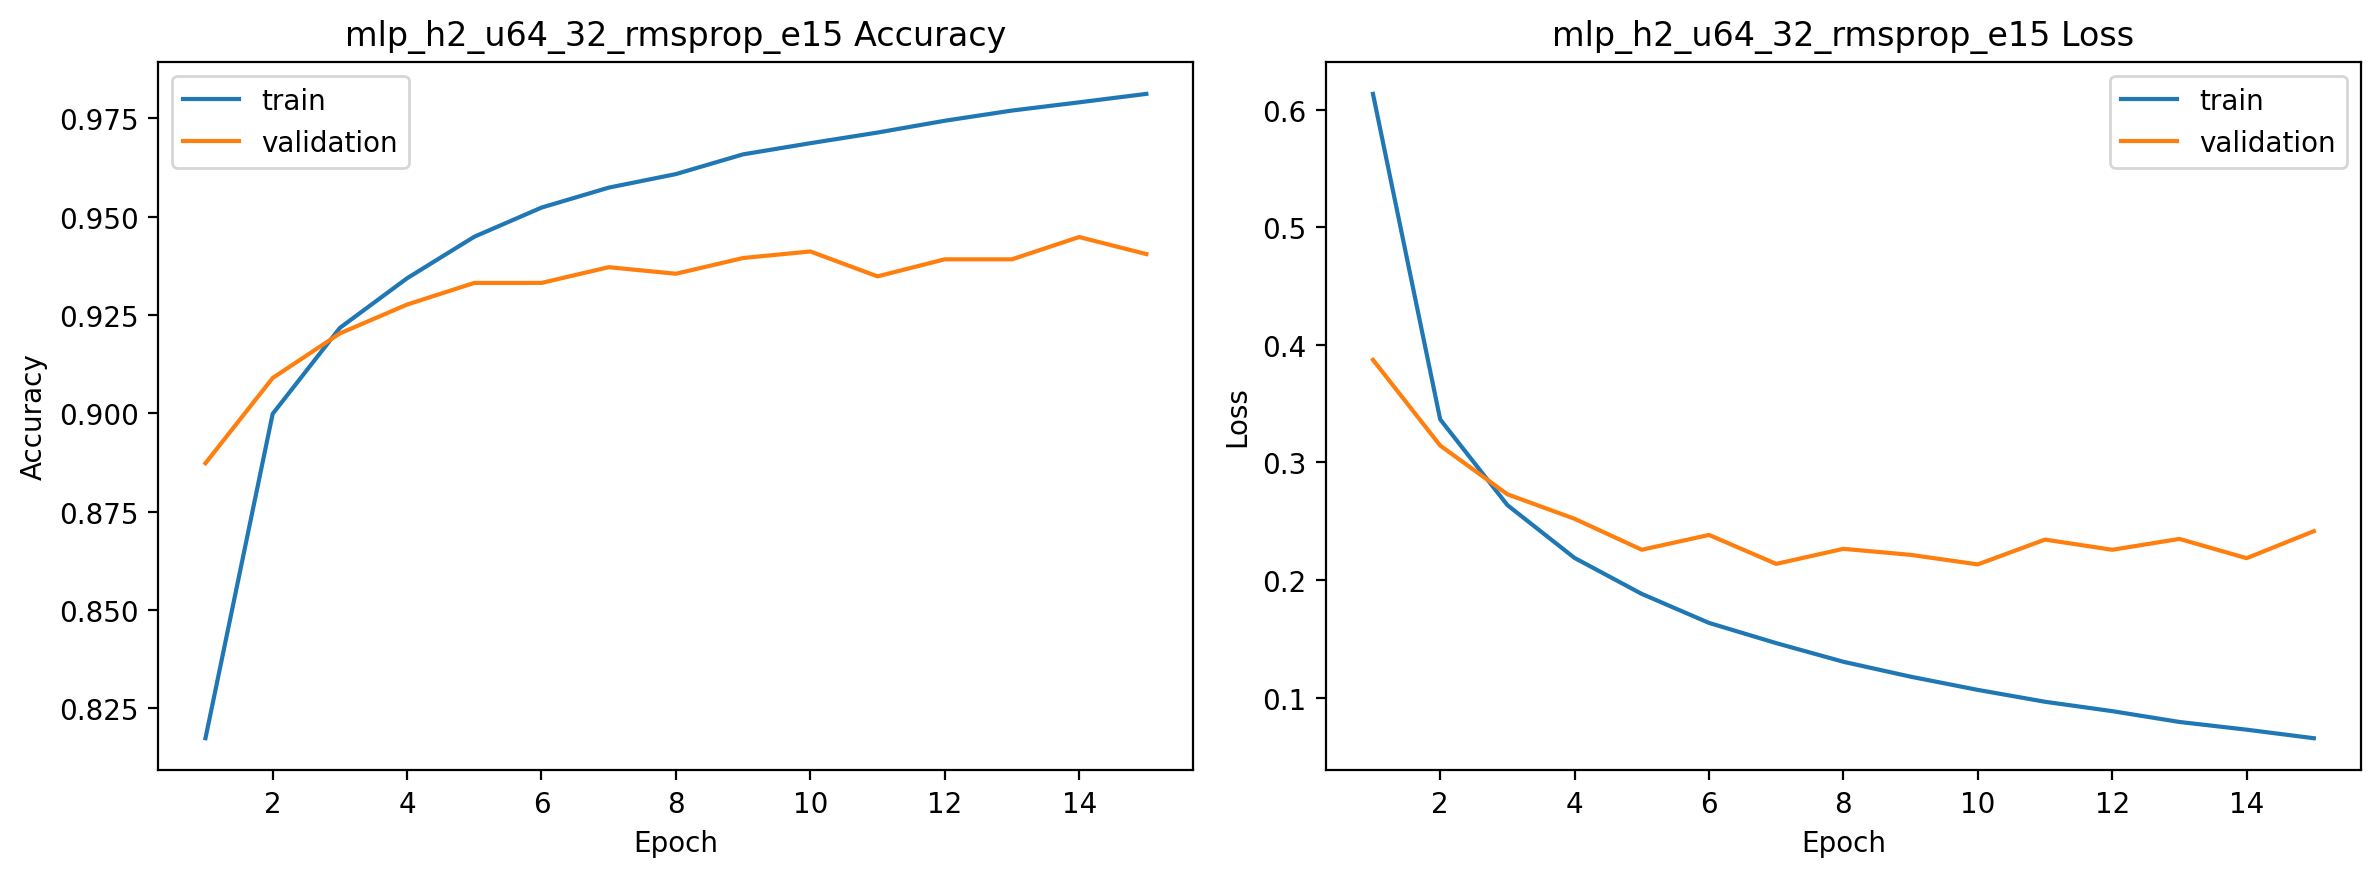

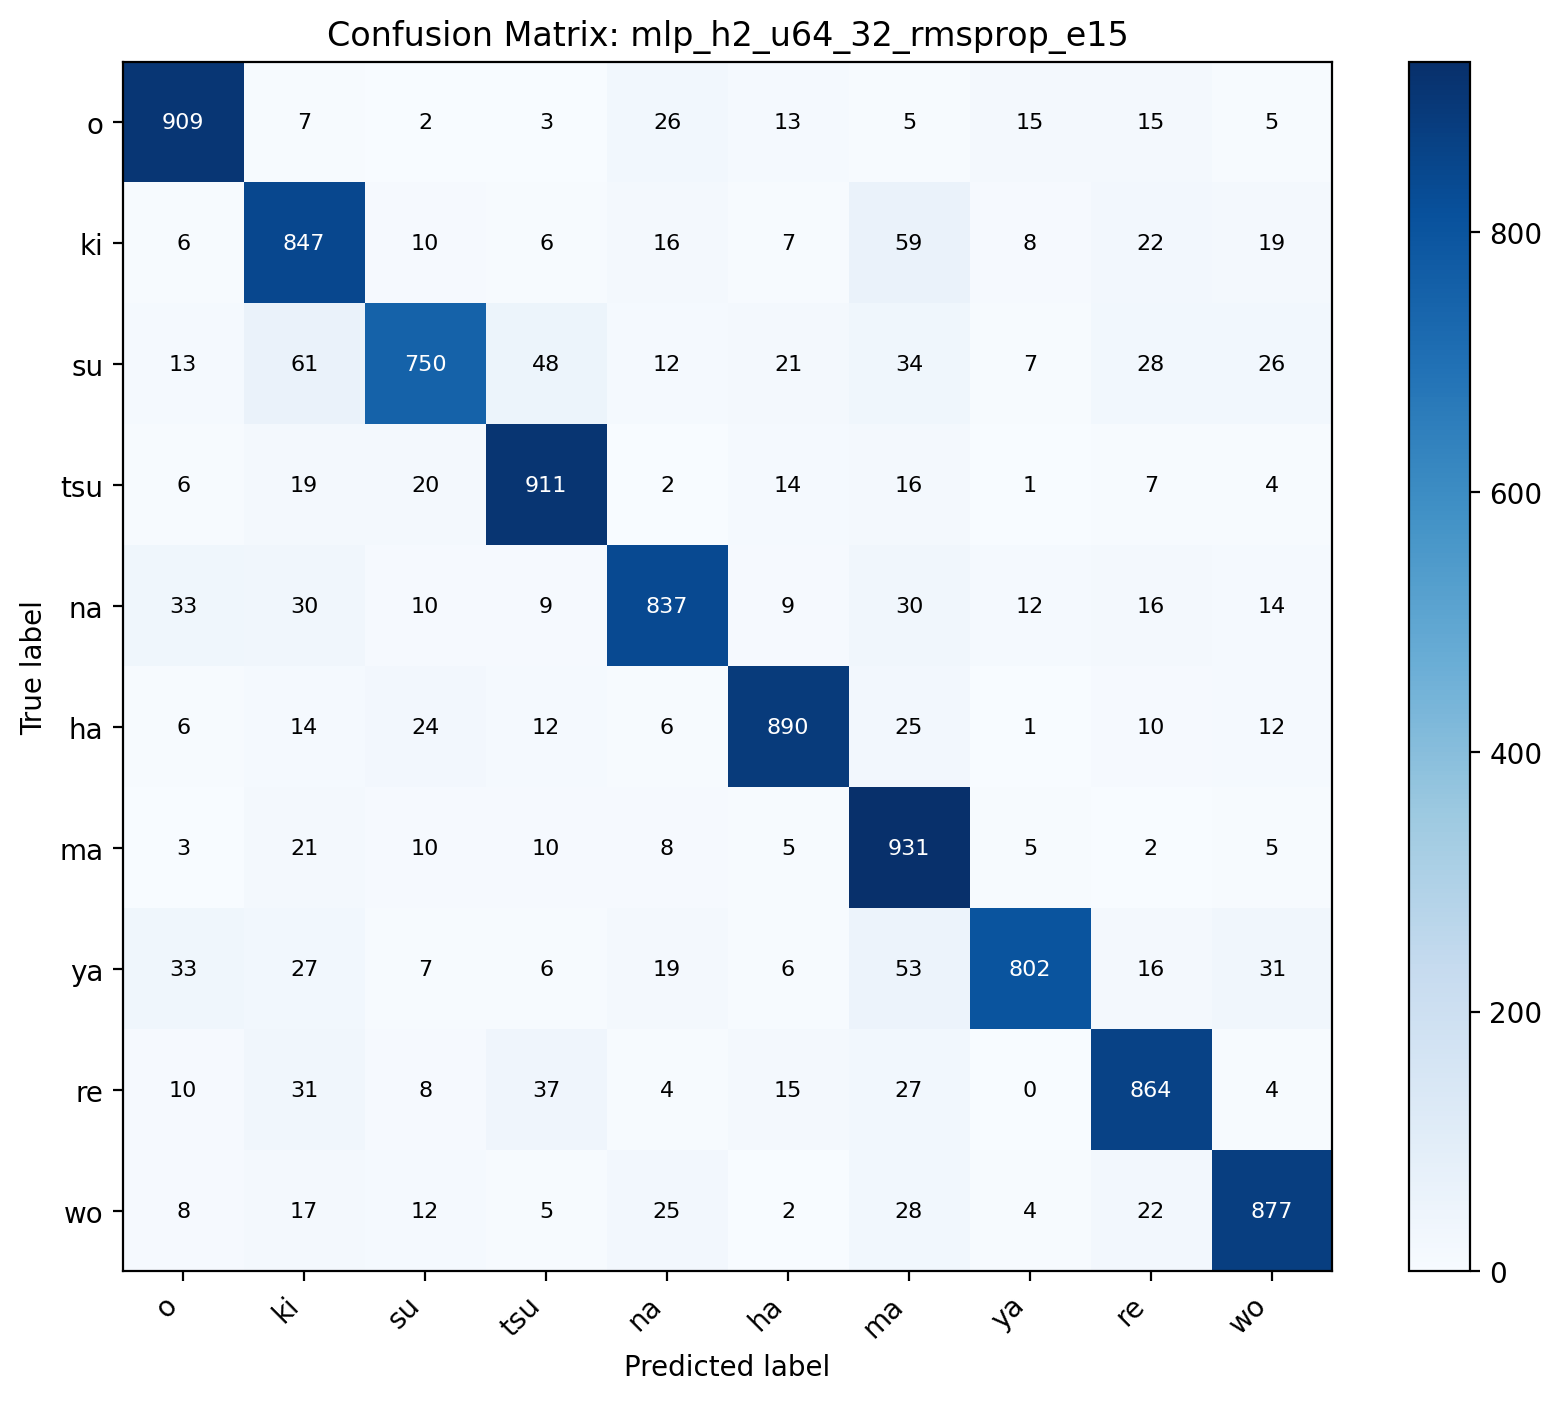

In [8]:
km.save_best_model_evaluation(best_mlp, test_images, test_labels)
km.save_best_history_plot(best_mlp)

mlp_eval_path = km.METRICS_DIR / f"{best_mlp.config_name}_evaluation.json"
with open(mlp_eval_path, "r", encoding="utf-8") as file:
    mlp_evaluation = json.load(file)

print(f"Best MLP overall test accuracy: {mlp_evaluation['overall_accuracy']:.4f}")
print("Per-class test accuracy:")
for row in mlp_evaluation["per_class_accuracy"]:
    print(f"- class {row['class_id']} ({row['class_name']}): {row['accuracy']:.4f} ({row['correct']}/{row['total']})")

display(Image(filename=str(km.FIGURES_DIR / f"{best_mlp.config_name}_history.png")))
display(Image(filename=str(km.FIGURES_DIR / f"{best_mlp.config_name}_confusion_matrix.png")))

## Small Convolutional Neural Network

- an input layer
- two convolutional layers with ReLU activations
- an optional 2x2 max-pooling layer during tuning
- a flatten layer
- two dense ReLU layers using the optimized MLP hidden widths
- a final dense softmax layer with 10 outputs

In [9]:
cnn_preview = km.build_cnn(
    conv1_filters=32,
    conv2_filters=64,
    kernel_size=3,
    use_pooling=True,
    unit_pair=best_dense_units,
    optimizer="adam",
)
cnn_preview.summary()

Model: "cnn_32_64_k3_pool_adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_49 (Flatten)            │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_125 (Dense)               │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,106 (3.14 MB)

 Trainable params: 824,106 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
cnn_results = km.run_cnn_search(
    train_images=train_images,
    train_labels=train_labels_split,
    val_images=val_images,
    val_labels=val_labels,
    test_images=test_images,
    test_labels=test_labels,
    dense_units=best_dense_units,
    config=km.FULL_CNN_CONFIG,
)
km.write_experiment_table(km.METRICS_DIR / "cnn_experiment_results.csv", cnn_results)

best_cnn = km.select_best_result(cnn_results)

sorted_cnn_results = sorted(
    cnn_results,
    key=lambda item: (item.best_val_accuracy, item.test_accuracy),
    reverse=True,
)

print(f"CNN experiments completed: {len(cnn_results)}")
print(f"Best CNN config: {best_cnn.config_name}")
print(f"Best CNN validation accuracy: {best_cnn.best_val_accuracy:.4f}")
print(f"Best CNN test accuracy: {best_cnn.test_accuracy:.4f}")
print("\nTop CNN runs:")
for result in sorted_cnn_results[:5]:
    print(
        f"- {result.config_name}: val={result.best_val_accuracy:.4f}, "
        f"test={result.test_accuracy:.4f}, params={result.params}"
    )

Epoch 1/10
422/422 - 14s - 33ms/step - accuracy: 0.8934 - loss: 0.3549 - val_accuracy: 0.9513 - val_loss: 0.1715
Epoch 2/10
422/422 - 13s - 30ms/step - accuracy: 0.9653 - loss: 0.1176 - val_accuracy: 0.9640 - val_loss: 0.1249
Epoch 3/10
422/422 - 12s - 29ms/step - accuracy: 0.9812 - loss: 0.0641 - val_accuracy: 0.9642 - val_loss: 0.1320
Epoch 4/10
422/422 - 12s - 29ms/step - accuracy: 0.9890 - loss: 0.0357 - val_accuracy: 0.9687 - val_loss: 0.1212
Epoch 5/10
422/422 - 12s - 28ms/step - accuracy: 0.9925 - loss: 0.0251 - val_accuracy: 0.9675 - val_loss: 0.1431
Epoch 6/10
422/422 - 12s - 27ms/step - accuracy: 0.9941 - loss: 0.0185 - val_accuracy: 0.9670 - val_loss: 0.1494
Epoch 7/10
422/422 - 12s - 28ms/step - accuracy: 0.9963 - loss: 0.0118 - val_accuracy: 0.9688 - val_loss: 0.1620
Epoch 8/10
422/422 - 12s - 28ms/step - accuracy: 0.9963 - loss: 0.0107 - val_accuracy: 0.9720 - val_loss: 0.1577
Epoch 9/10
422/422 - 12s - 27ms/step - accuracy: 0.9969 - loss: 0.0105 - val_accuracy: 0.9685 - 

Epoch 1/15
422/422 - 13s - 31ms/step - accuracy: 0.8990 - loss: 0.3362 - val_accuracy: 0.9558 - val_loss: 0.1527
Epoch 2/15
422/422 - 12s - 27ms/step - accuracy: 0.9680 - loss: 0.1079 - val_accuracy: 0.9662 - val_loss: 0.1177
Epoch 3/15
422/422 - 12s - 27ms/step - accuracy: 0.9826 - loss: 0.0578 - val_accuracy: 0.9650 - val_loss: 0.1327
Epoch 4/15
422/422 - 12s - 28ms/step - accuracy: 0.9903 - loss: 0.0323 - val_accuracy: 0.9698 - val_loss: 0.1237
Epoch 5/15
422/422 - 12s - 28ms/step - accuracy: 0.9928 - loss: 0.0218 - val_accuracy: 0.9655 - val_loss: 0.1469
Epoch 6/15
422/422 - 12s - 27ms/step - accuracy: 0.9946 - loss: 0.0167 - val_accuracy: 0.9715 - val_loss: 0.1321
Epoch 7/15
422/422 - 12s - 29ms/step - accuracy: 0.9967 - loss: 0.0115 - val_accuracy: 0.9722 - val_loss: 0.1364
Epoch 8/15
422/422 - 12s - 29ms/step - accuracy: 0.9968 - loss: 0.0104 - val_accuracy: 0.9732 - val_loss: 0.1320
Epoch 9/15
422/422 - 12s - 28ms/step - accuracy: 0.9961 - loss: 0.0124 - val_accuracy: 0.9725 - 

Epoch 1/10
422/422 - 12s - 28ms/step - accuracy: 0.8839 - loss: 0.3807 - val_accuracy: 0.9507 - val_loss: 0.1791
Epoch 2/10
422/422 - 12s - 28ms/step - accuracy: 0.9665 - loss: 0.1106 - val_accuracy: 0.9698 - val_loss: 0.1098
Epoch 3/10
422/422 - 11s - 26ms/step - accuracy: 0.9821 - loss: 0.0594 - val_accuracy: 0.9743 - val_loss: 0.1019
Epoch 4/10
422/422 - 12s - 29ms/step - accuracy: 0.9907 - loss: 0.0305 - val_accuracy: 0.9733 - val_loss: 0.1189
Epoch 5/10
422/422 - 12s - 28ms/step - accuracy: 0.9950 - loss: 0.0164 - val_accuracy: 0.9677 - val_loss: 0.1471
Epoch 6/10
422/422 - 11s - 27ms/step - accuracy: 0.9968 - loss: 0.0096 - val_accuracy: 0.9718 - val_loss: 0.1643
Epoch 7/10
422/422 - 11s - 25ms/step - accuracy: 0.9975 - loss: 0.0069 - val_accuracy: 0.9730 - val_loss: 0.1927
Epoch 8/10
422/422 - 11s - 26ms/step - accuracy: 0.9987 - loss: 0.0046 - val_accuracy: 0.9718 - val_loss: 0.1902
Epoch 9/10
422/422 - 11s - 26ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 0.9753 - 

Epoch 1/15
422/422 - 12s - 28ms/step - accuracy: 0.8715 - loss: 0.4261 - val_accuracy: 0.9495 - val_loss: 0.1733
Epoch 2/15
422/422 - 11s - 27ms/step - accuracy: 0.9648 - loss: 0.1200 - val_accuracy: 0.9617 - val_loss: 0.1371
Epoch 3/15
422/422 - 11s - 27ms/step - accuracy: 0.9794 - loss: 0.0686 - val_accuracy: 0.9682 - val_loss: 0.1145
Epoch 4/15
422/422 - 11s - 25ms/step - accuracy: 0.9883 - loss: 0.0404 - val_accuracy: 0.9717 - val_loss: 0.1188
Epoch 5/15
422/422 - 11s - 25ms/step - accuracy: 0.9933 - loss: 0.0232 - val_accuracy: 0.9725 - val_loss: 0.1374
Epoch 6/15
422/422 - 11s - 26ms/step - accuracy: 0.9964 - loss: 0.0131 - val_accuracy: 0.9672 - val_loss: 0.1768
Epoch 7/15
422/422 - 11s - 26ms/step - accuracy: 0.9964 - loss: 0.0103 - val_accuracy: 0.9698 - val_loss: 0.1637
Epoch 8/15
422/422 - 11s - 25ms/step - accuracy: 0.9984 - loss: 0.0062 - val_accuracy: 0.9698 - val_loss: 0.1925
Epoch 9/15
422/422 - 11s - 25ms/step - accuracy: 0.9987 - loss: 0.0041 - val_accuracy: 0.9718 - 

Epoch 1/10
422/422 - 11s - 26ms/step - accuracy: 0.8843 - loss: 0.3783 - val_accuracy: 0.9510 - val_loss: 0.1646
Epoch 2/10
422/422 - 9s - 21ms/step - accuracy: 0.9649 - loss: 0.1189 - val_accuracy: 0.9668 - val_loss: 0.1143
Epoch 3/10
422/422 - 9s - 22ms/step - accuracy: 0.9780 - loss: 0.0718 - val_accuracy: 0.9712 - val_loss: 0.1032
Epoch 4/10
422/422 - 10s - 23ms/step - accuracy: 0.9862 - loss: 0.0431 - val_accuracy: 0.9703 - val_loss: 0.1058
Epoch 5/10
422/422 - 9s - 22ms/step - accuracy: 0.9902 - loss: 0.0308 - val_accuracy: 0.9738 - val_loss: 0.0943
Epoch 6/10
422/422 - 9s - 21ms/step - accuracy: 0.9934 - loss: 0.0208 - val_accuracy: 0.9725 - val_loss: 0.1081
Epoch 7/10
422/422 - 9s - 21ms/step - accuracy: 0.9950 - loss: 0.0161 - val_accuracy: 0.9758 - val_loss: 0.1064
Epoch 8/10
422/422 - 8s - 20ms/step - accuracy: 0.9956 - loss: 0.0135 - val_accuracy: 0.9712 - val_loss: 0.1238
Epoch 9/10
422/422 - 9s - 20ms/step - accuracy: 0.9971 - loss: 0.0096 - val_accuracy: 0.9745 - val_los

...

Epoch 1/10
422/422 - 39s - 93ms/step - accuracy: 0.9019 - loss: 0.3218 - val_accuracy: 0.9578 - val_loss: 0.1412
Epoch 2/10
422/422 - 38s - 90ms/step - accuracy: 0.9731 - loss: 0.0925 - val_accuracy: 0.9738 - val_loss: 0.0923
Epoch 3/10
422/422 - 38s - 89ms/step - accuracy: 0.9841 - loss: 0.0533 - val_accuracy: 0.9742 - val_loss: 0.0894
Epoch 4/10
422/422 - 38s - 89ms/step - accuracy: 0.9905 - loss: 0.0305 - val_accuracy: 0.9788 - val_loss: 0.0848
Epoch 5/10
422/422 - 38s - 90ms/step - accuracy: 0.9926 - loss: 0.0226 - val_accuracy: 0.9735 - val_loss: 0.1102
Epoch 6/10
422/422 - 45s - 106ms/step - accuracy: 0.9941 - loss: 0.0173 - val_accuracy: 0.9840 - val_loss: 0.0783
Epoch 7/10
422/422 - 42s - 100ms/step - accuracy: 0.9961 - loss: 0.0124 - val_accuracy: 0.9820 - val_loss: 0.0910
Epoch 8/10
422/422 - 37s - 88ms/step - accuracy: 0.9957 - loss: 0.0124 - val_accuracy: 0.9817 - val_loss: 0.0984
Epoch 9/10
422/422 - 37s - 88ms/step - accuracy: 0.9962 - loss: 0.0105 - val_accuracy: 0.9778 

Epoch 1/15
422/422 - 39s - 92ms/step - accuracy: 0.8989 - loss: 0.3305 - val_accuracy: 0.9637 - val_loss: 0.1270
Epoch 2/15
422/422 - 37s - 88ms/step - accuracy: 0.9713 - loss: 0.0940 - val_accuracy: 0.9718 - val_loss: 0.0949
Epoch 3/15
422/422 - 37s - 89ms/step - accuracy: 0.9849 - loss: 0.0514 - val_accuracy: 0.9765 - val_loss: 0.0887
Epoch 4/15
422/422 - 37s - 88ms/step - accuracy: 0.9892 - loss: 0.0348 - val_accuracy: 0.9760 - val_loss: 0.0954
Epoch 5/15
422/422 - 38s - 89ms/step - accuracy: 0.9926 - loss: 0.0239 - val_accuracy: 0.9820 - val_loss: 0.0871
Epoch 6/15
422/422 - 37s - 88ms/step - accuracy: 0.9938 - loss: 0.0192 - val_accuracy: 0.9822 - val_loss: 0.0823
Epoch 7/15
422/422 - 37s - 88ms/step - accuracy: 0.9960 - loss: 0.0121 - val_accuracy: 0.9808 - val_loss: 0.0851
Epoch 8/15
422/422 - 37s - 88ms/step - accuracy: 0.9966 - loss: 0.0109 - val_accuracy: 0.9802 - val_loss: 0.0922
Epoch 9/15
422/422 - 37s - 88ms/step - accuracy: 0.9955 - loss: 0.0138 - val_accuracy: 0.9807 - 

Epoch 1/10
422/422 - 38s - 91ms/step - accuracy: 0.8843 - loss: 0.3797 - val_accuracy: 0.9653 - val_loss: 0.1284
Epoch 2/10
422/422 - 37s - 88ms/step - accuracy: 0.9734 - loss: 0.0926 - val_accuracy: 0.9733 - val_loss: 0.0999
Epoch 3/10
422/422 - 37s - 87ms/step - accuracy: 0.9857 - loss: 0.0487 - val_accuracy: 0.9817 - val_loss: 0.0776
Epoch 4/10
422/422 - 37s - 87ms/step - accuracy: 0.9917 - loss: 0.0274 - val_accuracy: 0.9805 - val_loss: 0.0855
Epoch 5/10
422/422 - 37s - 88ms/step - accuracy: 0.9951 - loss: 0.0165 - val_accuracy: 0.9755 - val_loss: 0.1216
Epoch 6/10
422/422 - 37s - 88ms/step - accuracy: 0.9969 - loss: 0.0109 - val_accuracy: 0.9830 - val_loss: 0.0959
Epoch 7/10
422/422 - 37s - 87ms/step - accuracy: 0.9977 - loss: 0.0077 - val_accuracy: 0.9835 - val_loss: 0.1144
Epoch 8/10
422/422 - 37s - 87ms/step - accuracy: 0.9982 - loss: 0.0056 - val_accuracy: 0.9817 - val_loss: 0.1329
Epoch 9/10
422/422 - 37s - 87ms/step - accuracy: 0.9988 - loss: 0.0036 - val_accuracy: 0.9830 - 

Epoch 1/15
422/422 - 38s - 90ms/step - accuracy: 0.8915 - loss: 0.3506 - val_accuracy: 0.9623 - val_loss: 0.1256
Epoch 2/15
422/422 - 37s - 87ms/step - accuracy: 0.9740 - loss: 0.0905 - val_accuracy: 0.9740 - val_loss: 0.0863
Epoch 3/15
422/422 - 40s - 95ms/step - accuracy: 0.9852 - loss: 0.0497 - val_accuracy: 0.9783 - val_loss: 0.0865
Epoch 4/15
422/422 - 38s - 89ms/step - accuracy: 0.9913 - loss: 0.0296 - val_accuracy: 0.9805 - val_loss: 0.0813
Epoch 5/15
422/422 - 37s - 87ms/step - accuracy: 0.9949 - loss: 0.0172 - val_accuracy: 0.9803 - val_loss: 0.0919
Epoch 6/15
422/422 - 37s - 87ms/step - accuracy: 0.9964 - loss: 0.0116 - val_accuracy: 0.9810 - val_loss: 0.1014
Epoch 7/15
422/422 - 37s - 88ms/step - accuracy: 0.9977 - loss: 0.0069 - val_accuracy: 0.9793 - val_loss: 0.1315
Epoch 8/15
422/422 - 37s - 87ms/step - accuracy: 0.9979 - loss: 0.0066 - val_accuracy: 0.9830 - val_loss: 0.1121
Epoch 9/15
422/422 - 37s - 87ms/step - accuracy: 0.9983 - loss: 0.0051 - val_accuracy: 0.9808 - 

CNN experiments completed: 24
Best CNN config: cnn_c32_64_k5_pool_adam_e15
Best CNN validation accuracy: 0.9843
Best CNN test accuracy: 0.9471

Top CNN runs:
- cnn_c32_64_k5_pool_adam_e15: val=0.9843, test=0.9471, params=857386
- cnn_c32_64_k5_pool_adam_e10: val=0.9840, test=0.9527, params=857386
- cnn_c32_64_k5_nopool_adam_e15: val=0.9838, test=0.9467, params=3265834
- cnn_c32_64_k5_pool_rmsprop_e10: val=0.9835, test=0.9525, params=857386
- cnn_c32_64_k5_pool_rmsprop_e15: val=0.9830, test=0.9487, params=857386


Best CNN overall test accuracy: 0.9471
Per-class test accuracy:
- class 0 (o): 0.9520 (952/1000)
- class 1 (ki): 0.9160 (916/1000)
- class 2 (su): 0.8960 (896/1000)
- class 3 (tsu): 0.9670 (967/1000)
- class 4 (na): 0.9170 (917/1000)
- class 5 (ha): 0.9420 (942/1000)
- class 6 (ma): 0.9810 (981/1000)
- class 7 (ya): 0.9670 (967/1000)
- class 8 (re): 0.9880 (988/1000)
- class 9 (wo): 0.9450 (945/1000)


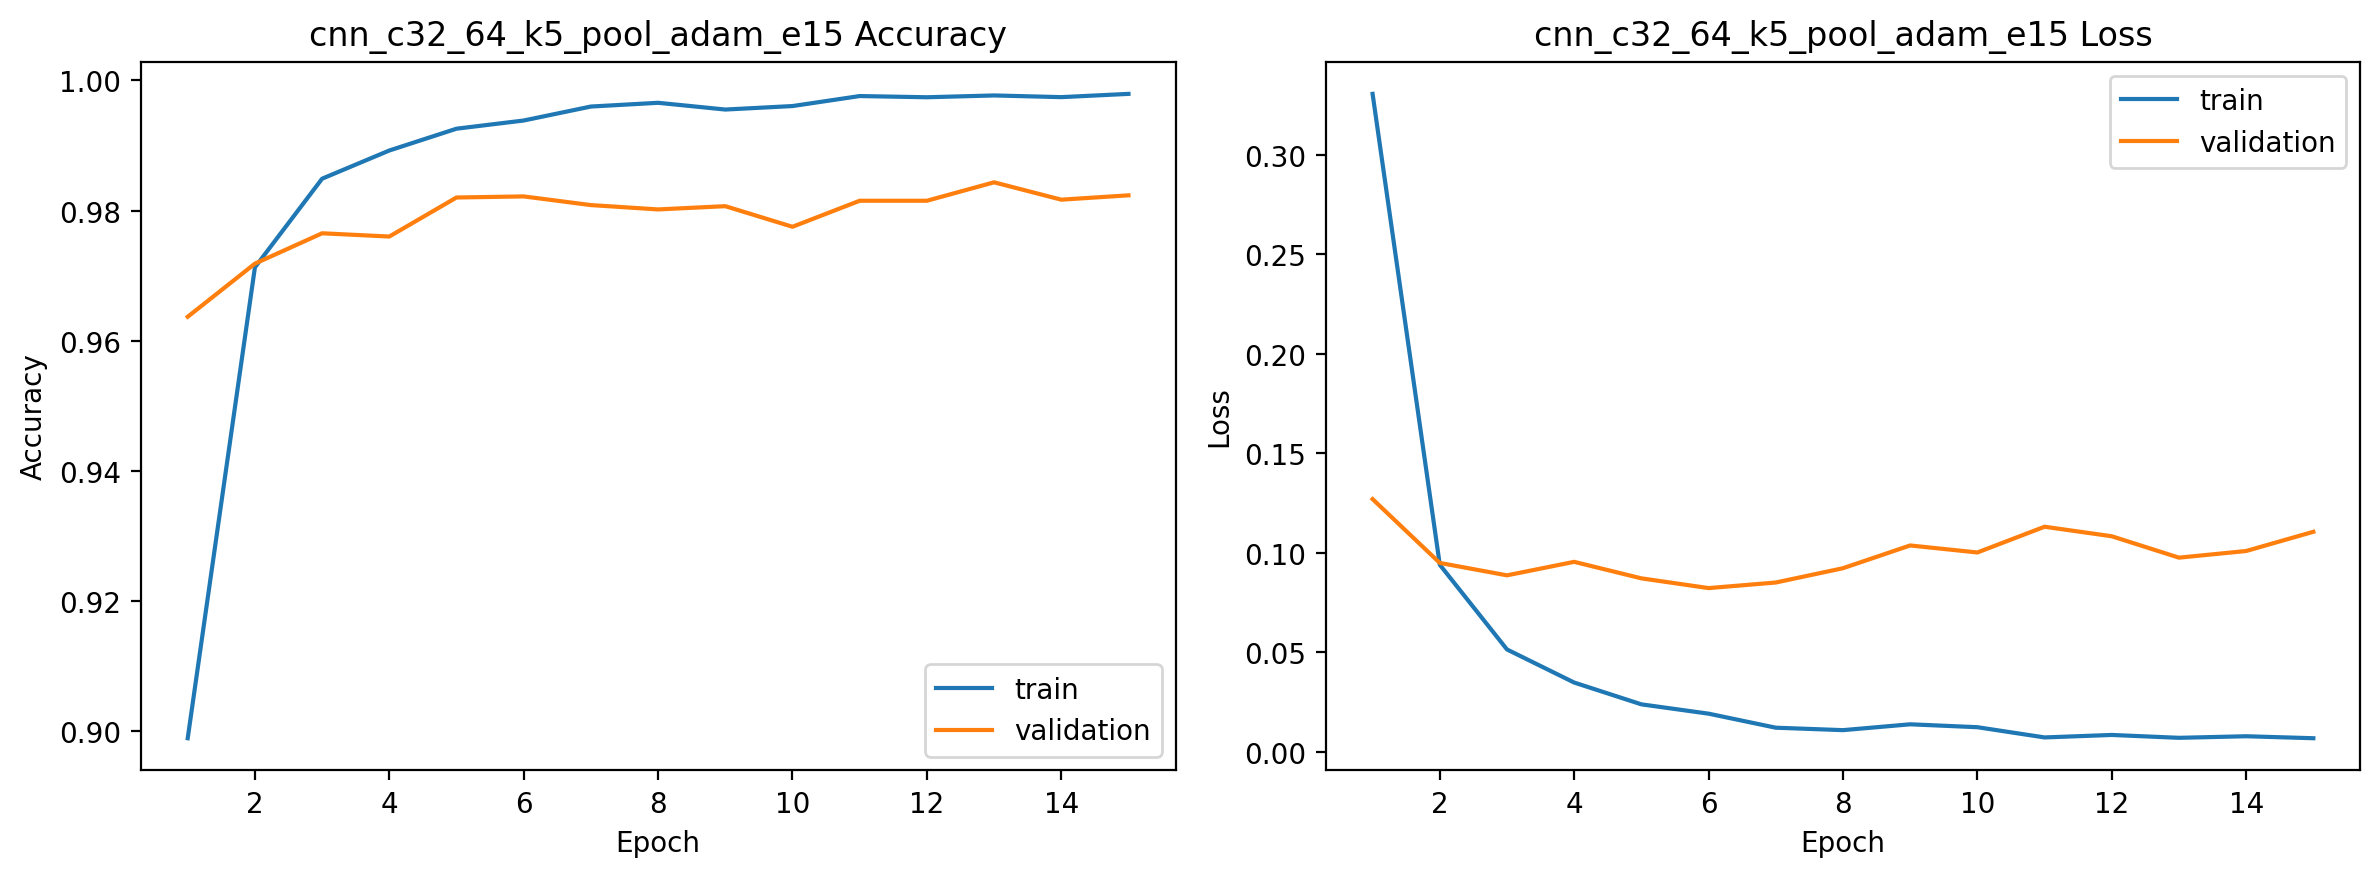

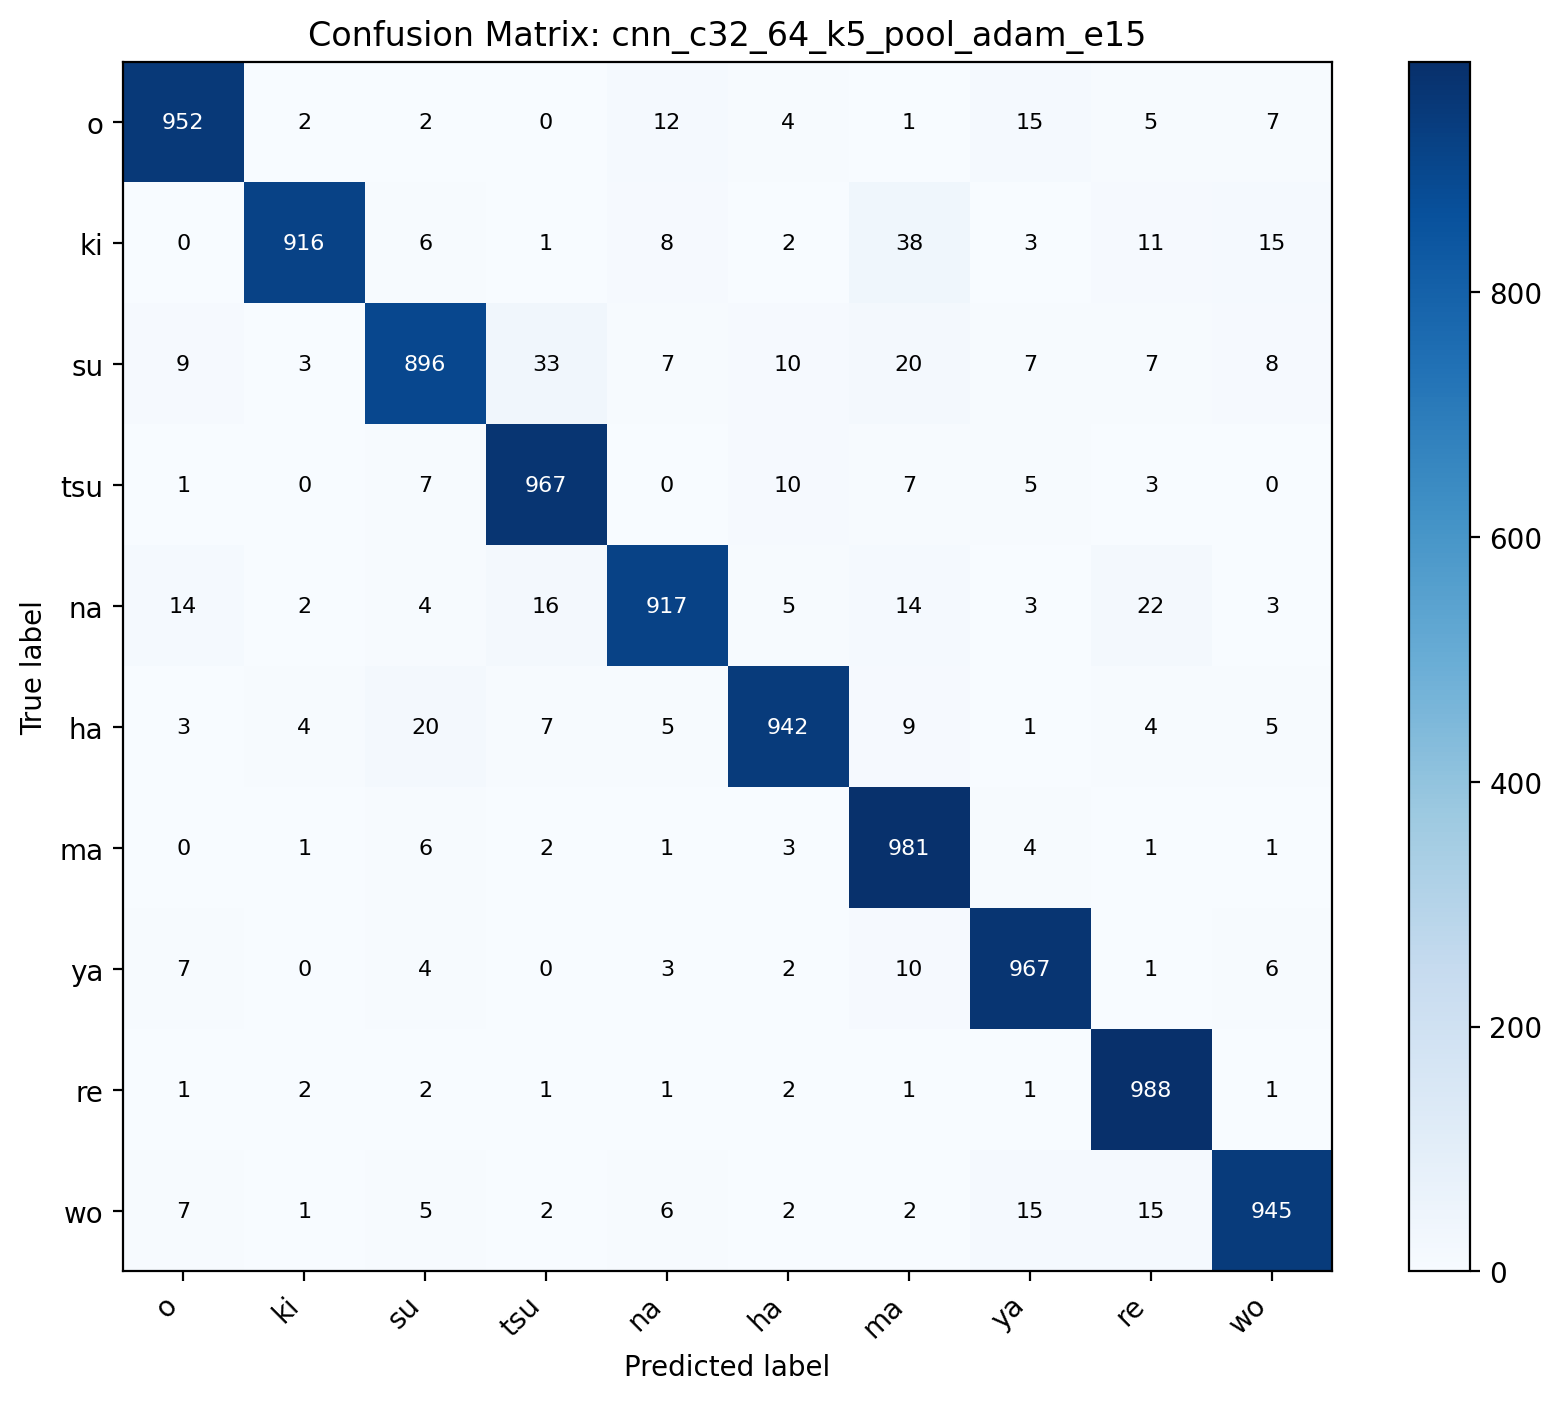

In [11]:
km.save_best_model_evaluation(best_cnn, test_images, test_labels)
km.save_best_history_plot(best_cnn)

cnn_eval_path = km.METRICS_DIR / f"{best_cnn.config_name}_evaluation.json"
with open(cnn_eval_path, "r", encoding="utf-8") as file:
    cnn_evaluation = json.load(file)

print(f"Best CNN overall test accuracy: {cnn_evaluation['overall_accuracy']:.4f}")
print("Per-class test accuracy:")
for row in cnn_evaluation["per_class_accuracy"]:
    print(f"- class {row['class_id']} ({row['class_name']}): {row['accuracy']:.4f} ({row['correct']}/{row['total']})")

display(Image(filename=str(km.FIGURES_DIR / f"{best_cnn.config_name}_history.png")))
display(Image(filename=str(km.FIGURES_DIR / f"{best_cnn.config_name}_confusion_matrix.png")))

In [12]:
summary_text = km.build_run_summary(mlp_results, cnn_results)
km.save_text(km.OUTPUT_DIR / "run_summary.txt", summary_text)
print(summary_text)

Project 3 KMNIST experiment run

Classification type: multiclass
Recommended loss: sparse_categorical_crossentropy
Reason for 10 output nodes: one softmax probability per KMNIST class

MLP experiments run: 48
Best MLP config: mlp_h2_u64_32_rmsprop_e15
Best MLP validation accuracy: 0.9448
Best MLP test accuracy: 0.8618

CNN experiments run: 24
Best CNN config: cnn_c32_64_k5_pool_adam_e15
Best CNN validation accuracy: 0.9843
Best CNN test accuracy: 0.9471

Saved outputs:
- figures/: sample grid, confusion matrices, training curves
- metrics/: dataset summary, experiment tables, evaluation JSON, training histories
- models/: saved Keras models
- summaries/: model architecture summaries
